In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [30]:
df=pd.read_csv("data/car_evaluation.tsv", sep='\t')
df

,buying_price,maintenance_costs,doors,seats,luggage_boot,safety,target
0,3,3,0,0,0,0,0
1,3,3,0,0,0,1,0
2,3,3,0,0,0,2,0
3,3,3,0,0,1,0,0
4,3,3,0,0,1,1,0
...,...,...,...,...,...,...,...
1723,0,0,3,2,1,1,2
1724,0,0,3,2,1,2,3
1725,0,0,3,2,2,0,0
1726,0,0,3,2,2,1,2


In [31]:
x_col= len(df.columns[:-1])

In [32]:
X = df.iloc[:, 0:x_col].values
print(X)

[[3 3 0 0 0 0]
 [3 3 0 0 0 1]
 [3 3 0 0 0 2]
 ...
 [0 0 3 2 2 0]
 [0 0 3 2 2 1]
 [0 0 3 2 2 2]]


In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder

y = df.iloc[:, -1].values
le = LabelEncoder()
y = le.fit_transform(y)


In [34]:
# Apply PCA
# reduce the data to 2 dimensions for easy visualization
# The 'n_components' parameter determines the target dimensionality
pca = PCA(n_components=3)

In [35]:
# Fit and transform the data simultaneously (unsupervised)
X_pca = pca.fit_transform(X_scaled, y)
print(f"Transformed shape of data: {X_pca.shape}")
print(
    f"Explained variance ratio of components: {pca.explained_variance_ratio_}")

Transformed shape of data: (1728, 3)
Explained variance ratio of components: [0.16666667 0.16666667 0.16666667]


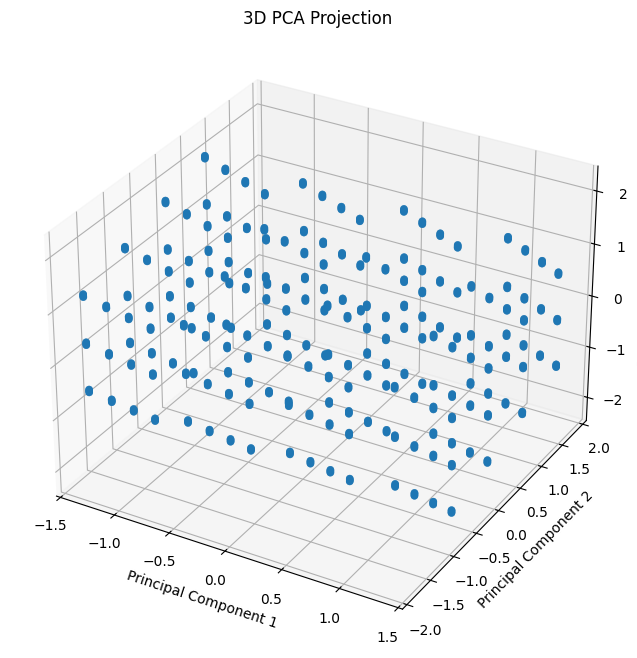

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA with 3 components
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled, y)

# 3D Figure
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    alpha=0.6
)

# Labels
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

ax.set_title('3D PCA Projection')

plt.show()

In [37]:
# Apply K-Means clustering to the PCA-transformed data for performing unsupervised classification
# 10 clusters as there are 10 different digits in the dataset
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

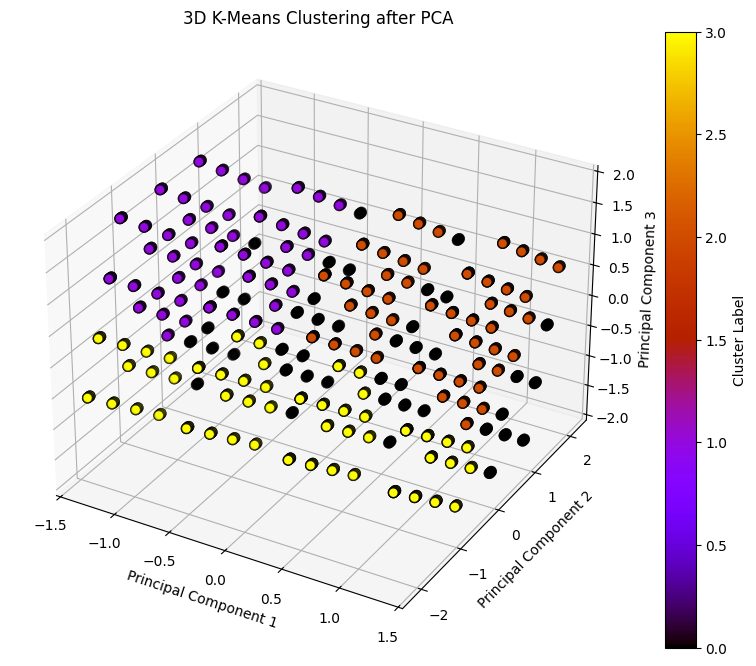

In [38]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# 3D Figure
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

# 3D Scatter Plot
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 2],
    X_pca[:, 1],
    c=clusters,
    cmap='gnuplot',
    edgecolor='k',
    s=50
)

# Labels
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

ax.set_title('3D K-Means Clustering after PCA')

# Colorbar
plt.colorbar(scatter, label='Cluster Label')
plt.savefig('Figure/PCA_KMeans_3D.pdf')
plt.show()

In [51]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
print(f"Transformed shape of data: {X_pca2.shape}")
print(f"Explained variance ratio of components: {pca2.explained_variance_ratio_}")


Transformed shape of data: (1728, 2)
Explained variance ratio of components: [0.16666667 0.16666667]


In [52]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca2)

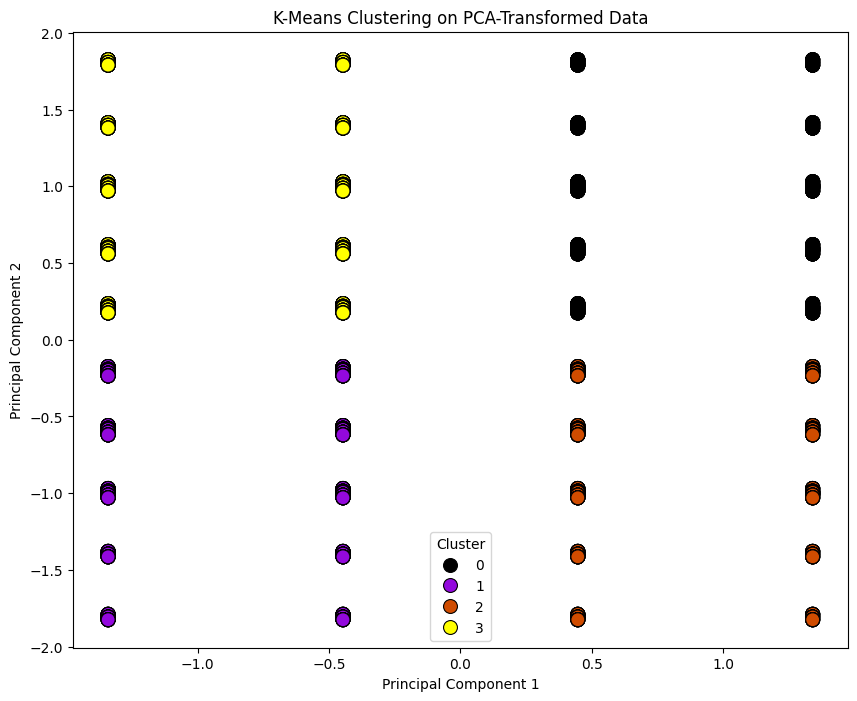

In [53]:
# plot clustering
import seaborn as sns
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    y=X_pca2[:, 1],
    x=X_pca2[:, 0],
    hue=clusters,
    palette='gnuplot',
    edgecolor='k',
    s=100
)
plt.title('K-Means Clustering on PCA-Transformed Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.savefig('Figure/PCA_KMeans_2D.pdf')
plt.show()    

# LDA

In [54]:


lda = LinearDiscriminantAnalysis(n_components=3)

In [55]:
# Fit and transform the data using class labels (supervised)
X_lda = lda.fit_transform(X_scaled, y)
print(f"Transformed shape of data: {X_lda.shape}")
print(f"Explained variance ratio of components: {lda.explained_variance_ratio_}")

Transformed shape of data: (1728, 3)
Explained variance ratio of components: [0.92495396 0.06238267 0.01266337]


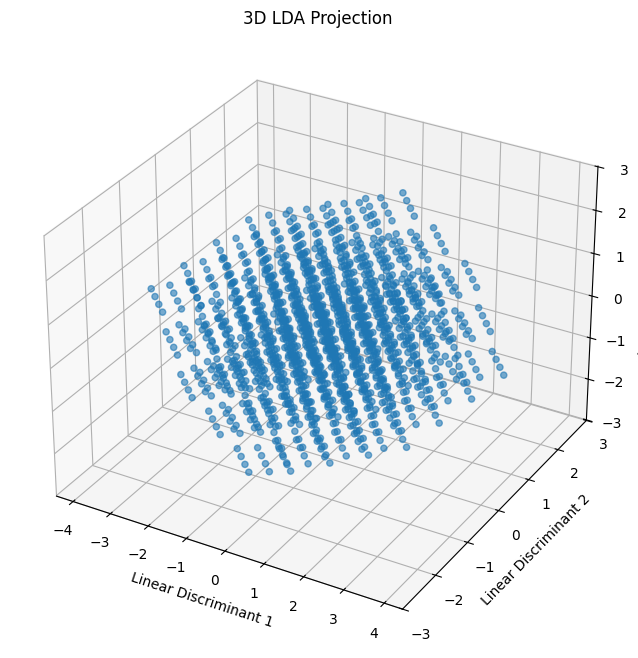

In [56]:
# LDA with 3 components
lda = LinearDiscriminantAnalysis(n_components=3)

X_lda = lda.fit_transform(X_scaled, y)

# 3D Figure
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(
    X_lda[:, 0],
    X_lda[:, 1],
    X_lda[:, 2],
    alpha=0.6
)

# Labels
ax.set_xlabel('Linear Discriminant 1')
ax.set_ylabel('Linear Discriminant 2')
ax.set_zlabel('Linear Discriminant 3')

ax.set_title('3D LDA Projection')

plt.show()

In [57]:
# Apply K-Means clustering to the LDA-transformed data
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_lda)

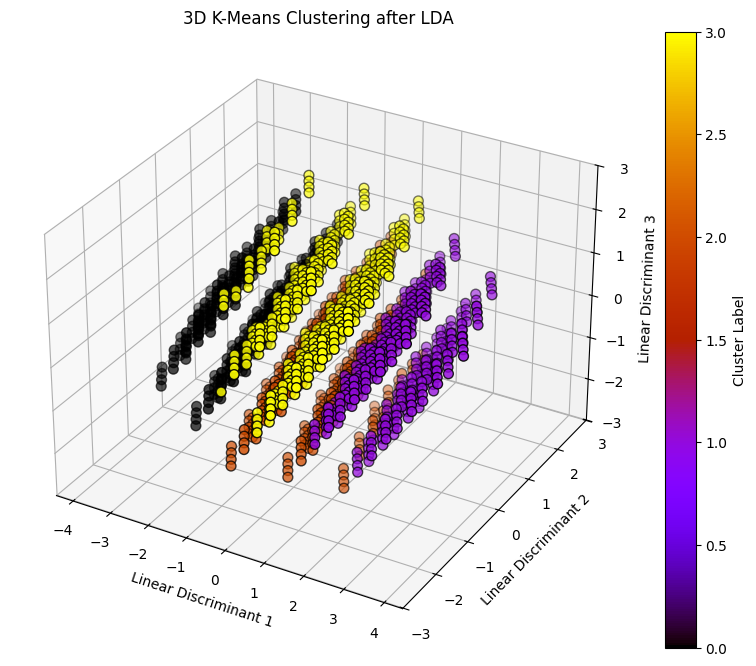

In [58]:
# 3D Figure
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

# 3D Scatter Plot
scatter = ax.scatter(
    X_lda[:, 0],
    X_lda[:, 2],
    X_lda[:, 1],
    c=clusters,
    cmap='gnuplot',
    edgecolor='k',
    s=50
)

# Labels
ax.set_xlabel('Linear Discriminant 1')
ax.set_ylabel('Linear Discriminant 2')
ax.set_zlabel('Linear Discriminant 3')

ax.set_title('3D K-Means Clustering after LDA')

# Colorbar
plt.colorbar(scatter, label='Cluster Label')
plt.savefig('Figure/LDA_KMeans_3D.pdf')
plt.show()

In [59]:
lda2 = LinearDiscriminantAnalysis(n_components=2)
X_lda2 = lda2.fit_transform(X_scaled, y)
print(f"Transformed shape of data: {X_lda2.shape}")
print(f"Explained variance ratio of components: {lda2.explained_variance_ratio_}")

Transformed shape of data: (1728, 2)
Explained variance ratio of components: [0.92495396 0.06238267]


In [60]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_lda2)

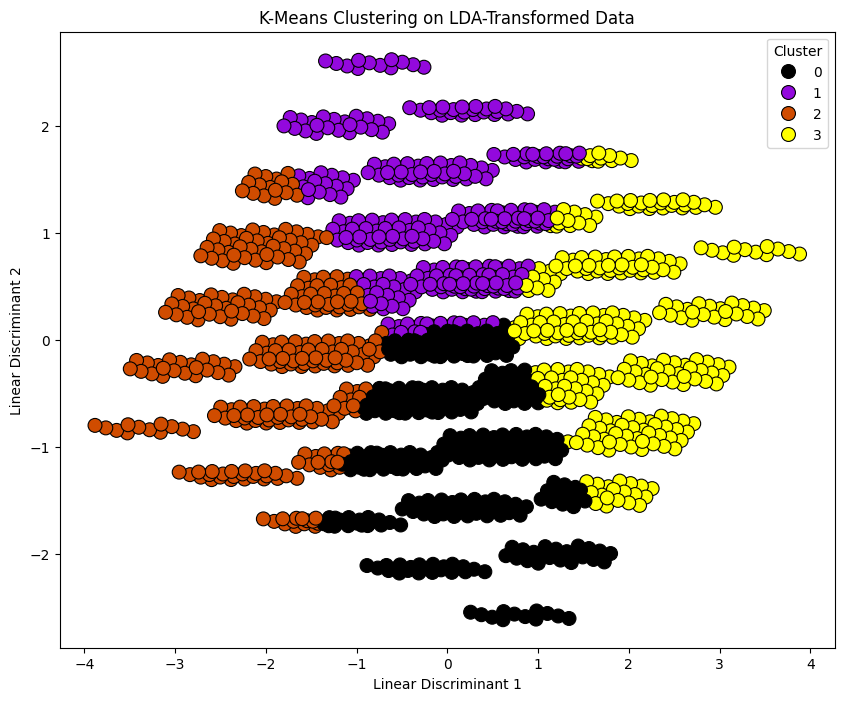

In [61]:
# plot clustering
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    y=X_lda2[:, 1],
    x=X_lda2[:, 0],
    hue=clusters,
    palette='gnuplot',
    edgecolor='k',
    s=100
)
plt.title('K-Means Clustering on LDA-Transformed Data')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.legend(title='Cluster')
plt.savefig('Figure/LDA_KMeans_2D.pdf')
plt.show()